In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
FP=pd.read_csv("/content/drive/MyDrive/ames_data/AmesHousing_features.csv")

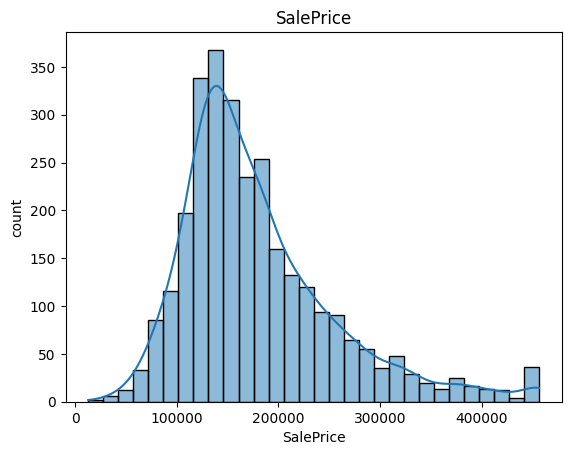

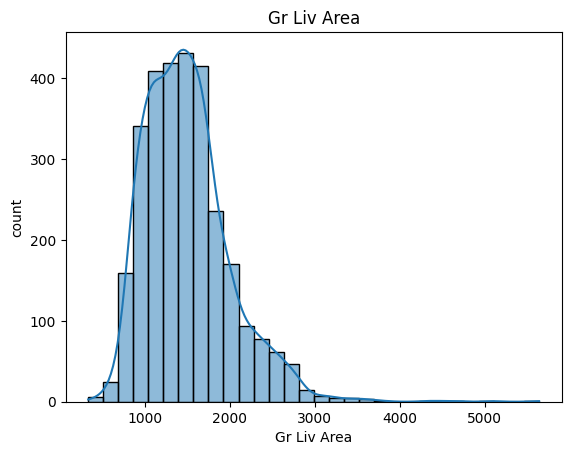

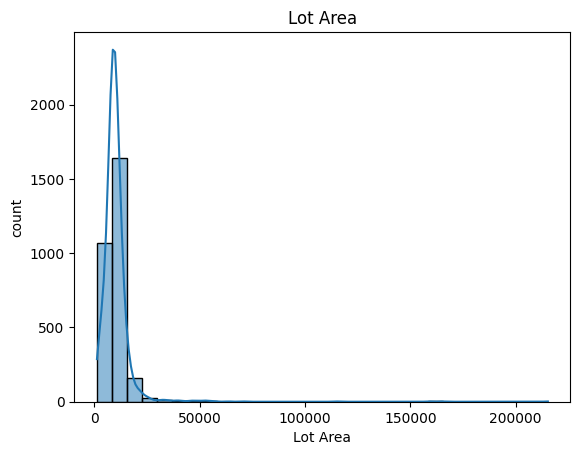

In [ ]:
sns.histplot(FP["SalePrice"],bins=30,kde=True)
plt.title("SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("count")
plt.show()
sns.histplot(FP["Gr Liv Area"],bins=30,kde=True)
plt.title("Gr Liv Area")
plt.xlabel("Gr Liv Area")
plt.ylabel("count")
plt.show()
sns.histplot(FP["Lot Area"],bins=30,kde=True)
plt.title("Lot Area")
plt.xlabel("Lot Area")
plt.ylabel("count")
plt.show()

The three numerical distributions are not identical in shape. SalePrice and Lot Area are right-skewed, which means most homes are clustered at lower values while a smaller number of homes have very large values. Gr Liv Area is also slightly right-skewed, but it is more concentrated around the middle compared with Lot Area.

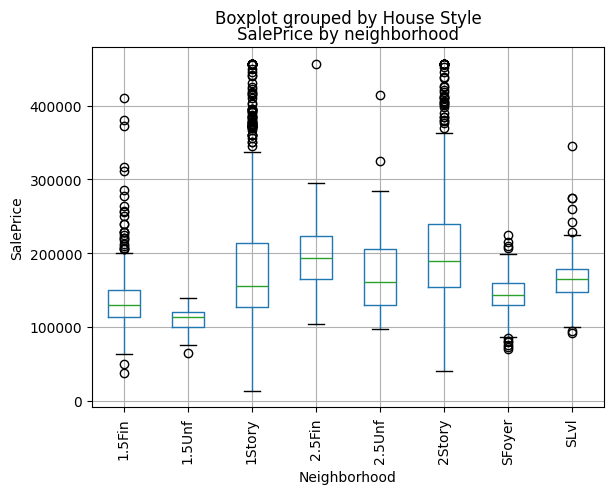

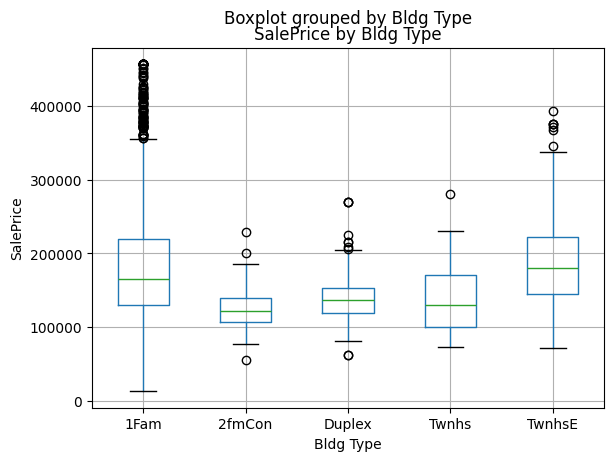

In [ ]:
FP.boxplot(column="SalePrice",by="House Style")
plt.xticks(rotation=90)
plt.title("SalePrice by neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.show()

FP.boxplot(column="SalePrice",by="Bldg Type")
plt.title("SalePrice by Bldg Type")
plt.xlabel("Bldg Type")
plt.ylabel("SalePrice")
plt.show()

The grouped boxplots show that is SalePrice can changes across categories. Neighborhood clearly has a strong effect on price, because we have some areas have much higher median prices and wider ranges than others. House Style also matters, although its effect appears smaller than the effect of location.

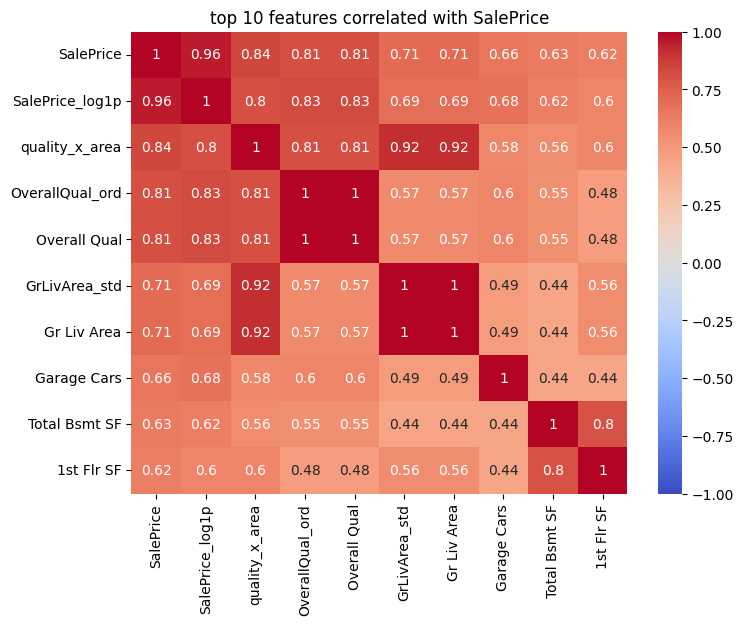

In [ ]:
corr_matrix=FP.select_dtypes(include=["number"]).corr()
top10=corr_matrix["SalePrice"].abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(8,6))
sns.heatmap(FP[top10].corr(),annot=True,cmap="coolwarm",vmin=-1,vmax=1)
plt.title("top 10 features correlated with SalePrice")
plt.show()

The grouped boxplots show that SalePrice changes across categories. Neighborhood clearly has a strong effect on price, because some areas have much higher median prices and wider ranges than others. House Style also matters, although its effect appears smaller than the effect of location.

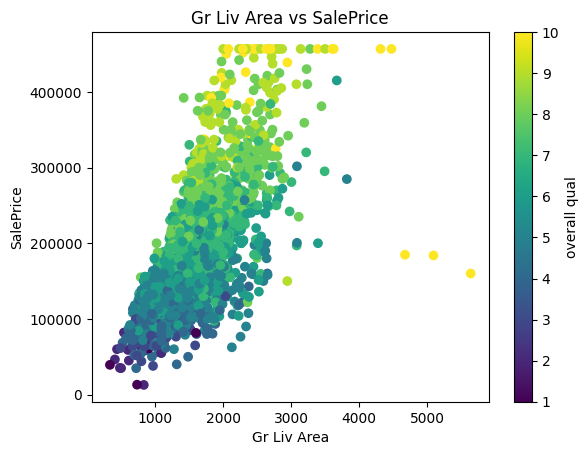

In [ ]:
plt.scatter(FP["Gr Liv Area"],FP["SalePrice"],c=FP["Overall Qual"],cmap="viridis")
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")
plt.title("Gr Liv Area vs SalePrice")
plt.colorbar(label="overall qual")
plt.show()

The scatter plot shows a positive relationship between living area and SalePrice. In general, larger homes tend to have higher prices, and the color scale shows that homes with better overall quality often appear in the higher-price region. This means that both size and quality help explain variation in price.

In [ ]:
group_mean=FP.groupby("House Style")["SalePrice"].mean()
print("highest mean SalePrice:")
print(group_mean.sort_values(ascending=False).head())
print("lowest mean SalePrice`:")
print(group_mean.sort_values().head())


highest mean SalePrice:
House Style
2.5Fin    217708.296250
2Story    205351.836403
1Story    178017.416307
2.5Unf    177158.333333
SLvl      165527.382812
Name: SalePrice, dtype: float64
lowest mean SalePrice`:
House Style
1.5Unf    109663.157895
1.5Fin    137529.923567
SFoyer    143472.662651
SLvl      165527.382812
2.5Unf    177158.333333
Name: SalePrice, dtype: float64


The groupby summary compares the average SalePrice across neighborhoods. The highest-price neighborhoods have much larger average values than the lowest-price neighborhoods, which confirms that location is an important factor in the Ames Housing dataset. This also supports the earlier boxplot finding that neighborhood has a strong effect on house value.

In [ ]:
price=FP["SalePrice"].values
mean=np.sum(price)/len(price)
std=np.sqrt(np.sum((price-mean)**2)/len(price))
print("manual mean:",mean)
print("manual std",std)

manual mean: 179956.70481228668
manual std 76061.61121141634


I calculated the average house price (mean) and how much prices vary (standard deviation). The mean shows the typical price, and the standard deviation shows how spread out the prices are.

In [ ]:
x=FP["Gr Liv Area"].values
mean_x=np.sum(x)/len(x)
std_x=np.sqrt(np.sum((x-mean_x)**2)/len(x))

z_manual=(x-mean_x)/std_x

scaler=StandardScaler()
z_sklearn=scaler.fit_transform(x.reshape(-1,1)).flatten()
print("manual z-socre f5:",z_manual[:5])
print("StandardScaler first f5:",z_sklearn[:5])

manual z-socre f5: [ 0.30926506 -1.19442705 -0.33771825  1.20752324  0.25584442]
StandardScaler first f5: [ 0.30926506 -1.19442705 -0.33771825  1.20752324  0.25584442]


I standardised "Gr Liv Area" manually and compared it with StandardScaler. The results are similar, which confirms the calculation. This helps put values on the same scale.

In [ ]:
numeric_cols=FP.select_dtypes(include=["number"]).drop(columns=["SalePrice"]).columns
high_vec=FP.loc[FP["SalePrice"].idxmax(),numeric_cols].values
low_vec=FP.loc[FP["SalePrice"].idxmin(),numeric_cols].values
cosine_similarity=np.dot(high_vec,low_vec)/(np.linalg.norm(high_vec)*np.linalg.norm(low_vec))
print("cosine similarity",cosine_similarity)



cosine similarity 0.999999994697387


I measured how similar the most expensive house and the cheapest house are. A higher value means they are more similar, while a lower value means they are different.

In [ ]:
high_quality=FP[FP["Overall Qual"]>=8]
probab=len(high_quality[high_quality["SalePrice"]>300000])/len(high_quality)

print("Probability:",probab)

Probability: 0.4323770491803279


I calculated the probability that high-quality houses (Overall Qual ≥ 8) have a price above 300000. This shows how strongly quality is related to price.

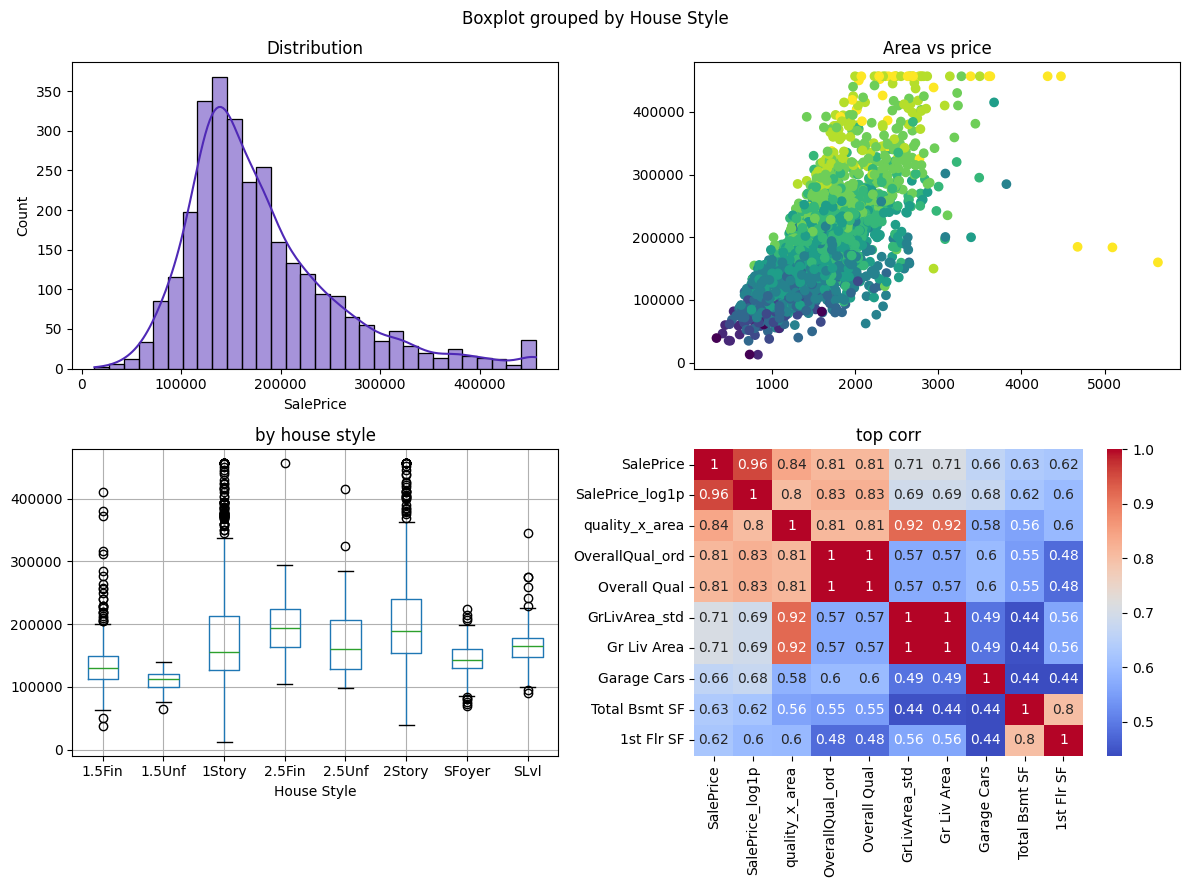

In [ ]:
corr_matrix=FP.select_dtypes(include=["number"]).corr()
top10=corr_matrix["SalePrice"].abs().sort_values(ascending=False).head(10).index
fig,axes=plt.subplots(2,2,figsize=(12,9))
fig.suptitle("Ames housing dashboard",fontsize=18,fontweight="bold")

sns.histplot(FP["SalePrice"],bins=30,kde=True,ax=axes[0,0],color="#4f29b6")
axes[0,0].set_title("Distribution")

axes[0,1].scatter(FP["Gr Liv Area"],FP["SalePrice"],c=FP["Overall Qual"],cmap="viridis")
axes[0,1].set_title("Area vs price")

FP.boxplot(column="SalePrice",by="House Style",ax=axes[1,0])
axes[1,0].set_title("by house style")
sns.heatmap(FP[top10].corr(),annot=True,cmap="coolwarm")
axes[1,1].set_title("top corr")
plt.tight_layout()
plt.show()

